In [ ]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
dt = ds.Coco("/home/wanderer2414/coco2017/")

In [ ]:
# import MyRCNN
# import torch
# model = MyRCNN.Model(device=torch.device("cpu"))
# model.model.load_state_dict(torch.load("bbx.pth", map_location="cpu"))

In [ ]:
import MyRCNN
import torch
model = MyRCNN.Model(device=torch.device("cuda"))
model.train(dt)

[00:02:10] 2.0717194080352783             ██████████████████████████████████████████████████████████ 50       /       50


In [ ]:

from torch import stack
import torch
from torch import Tensor
def nms(boxes: Tensor)->Tensor:
    N = boxes.shape[0]
    rows, cols = torch.meshgrid(torch.arange(N, device=boxes.device), torch.arange(N, device=boxes.device), indexing='ij')
    
    boxes1 = boxes.unsqueeze(1).expand(N, N, 4)
    boxes2 = boxes.unsqueeze(0).expand(N, N, 4)
    x1 = torch.max(boxes1[:, :, 0], boxes2[:, :, 0])
    x2 = torch.min(boxes1[:, :, 2], boxes2[:, :, 2])
    w = x2 - x1
    del x1, x2
    y1 = torch.max(boxes1[:, :, 1], boxes2[:, :, 1])
    y2 = torch.min(boxes1[:, :, 3], boxes2[:, :, 3])
    h = y2-y1
    del y2, y1
    s = ((boxes[:, 2]-boxes[:, 0])*(boxes[:, 3] - boxes[:, 1]))
    s = s.unsqueeze(1).expand(N, N) + s.unsqueeze(0).expand(N, N)
    intersect = w*h
    IoU = intersect/(s - intersect)
    IoU = IoU * (rows>cols)
    cond = IoU > 0.6
    indices = (cond.any(dim=1).logical_not())
    
    return boxes[indices]

def mode_pool2d(x, kernel_size=3, stride=1, padding=0) -> Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    median = patches.mode(dim=2).values
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return median.view(B, C, H_out, W_out)


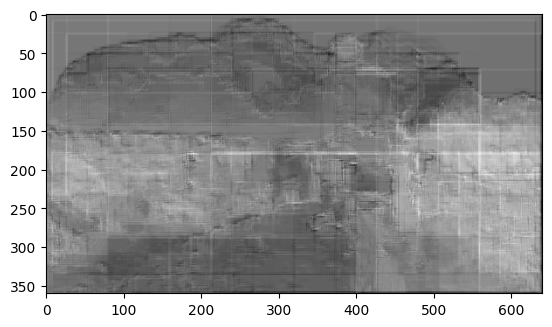

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from dataset import TensorToImg, ImgToTensor
x = dt.getTrainTensor(0).to(device=torch.device("cuda"))
# x = x[:, :, 0:350, 250:600]
mask, color, result = model.model(x)
# boxes = result[1][:, :, 1:].squeeze(0)
# boxes = nms(boxes)
# for box in boxes:
#     x1, y1, x2, y2 = box.detach().cpu().numpy()
#     rect = pat.Rectangle((x1, y1), x2, y2, facecolor='none', edgecolor='red')
#     plt.subplot().add_patch(rect)
x = (x*255/16).round()*16/256
x = mode_pool2d(x, 11, 1, 5)
prep = model.model.color.prepare(x)
down1 = model.model.color.downgrade(prep)
down2 = model.model.color.downgrade(down1)
down3 = model.model.color.downgrade(down2)
score = model.model.feat.bbx.score(color)
x = score[:, 0:1, :, :]
x = x.repeat(1, 3, 1, 1)
x = x-x.min()
x = x/x.max()
# ImgWrite("filtercolor.png", TensorToImg(x.detach().cpu()))
plt.imshow(TensorToImg(x.detach().cpu()))

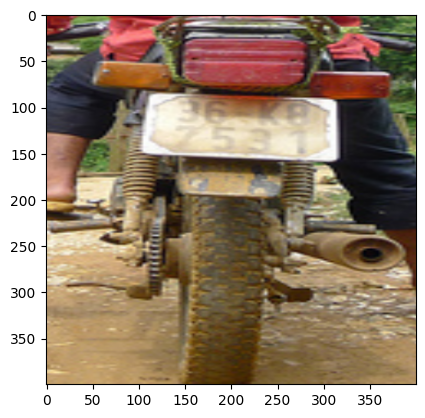

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from torchvision.ops import roi_align
from dataset import TensorToImg, ImgToTensor
i = 0
x = dt.getTrainTensor(i).to(device=torch.device("cuda"))
label = dt.getTrainLabel(i).to(device=torch.device("cuda"))
mask, color, result = model.model(x)
boxes = label[:, :-1]
x = roi_align(x, [boxes], (400, 400))
cls = model.cls(mask, color, boxes)
plt.imshow(TensorToImg(x.detach().cpu()))
cls_label = label[:, -1]
# print(cls_label)
# print(cls_label, cls[cls_label.long()])